In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment is ready.")

Environment is ready.


In [3]:
import sys
print(sys.executable)

c:\Users\jacob\macrosense-equity-attribution\.venv\Scripts\python.exe


In [4]:
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article")
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Charts will save to:", OUTPUT_DIR)

Project root: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article
Charts will save to: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs


In [5]:
def download_prices(tickers, start="2025-01-01", end=None):
    data = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False
    )

    if data.empty:
        raise ValueError("No data downloaded. Check tickers, dates, or internet connection.")

    if isinstance(data.columns, pd.MultiIndex):
        prices = data["Close"]
    else:
        ticker_name = tickers if isinstance(tickers, str) else tickers[0]
        prices = data[["Close"]].rename(columns={"Close": ticker_name})

    prices = prices.dropna(axis=1, how="all")
    prices = prices.ffill()

    return prices


def index_prices(prices):
    indexed = prices.copy()

    for col in indexed.columns:
        first_valid = indexed[col].dropna().iloc[0]
        indexed[col] = indexed[col] / first_valid * 100

    return indexed


def calculate_drawdowns(prices):
    rolling_peak = prices.cummax()
    drawdowns = (prices / rolling_peak - 1) * 100
    return drawdowns


def save_chart(filename):
    path = OUTPUT_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)

Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_1_bizd_vs_public_markets.png


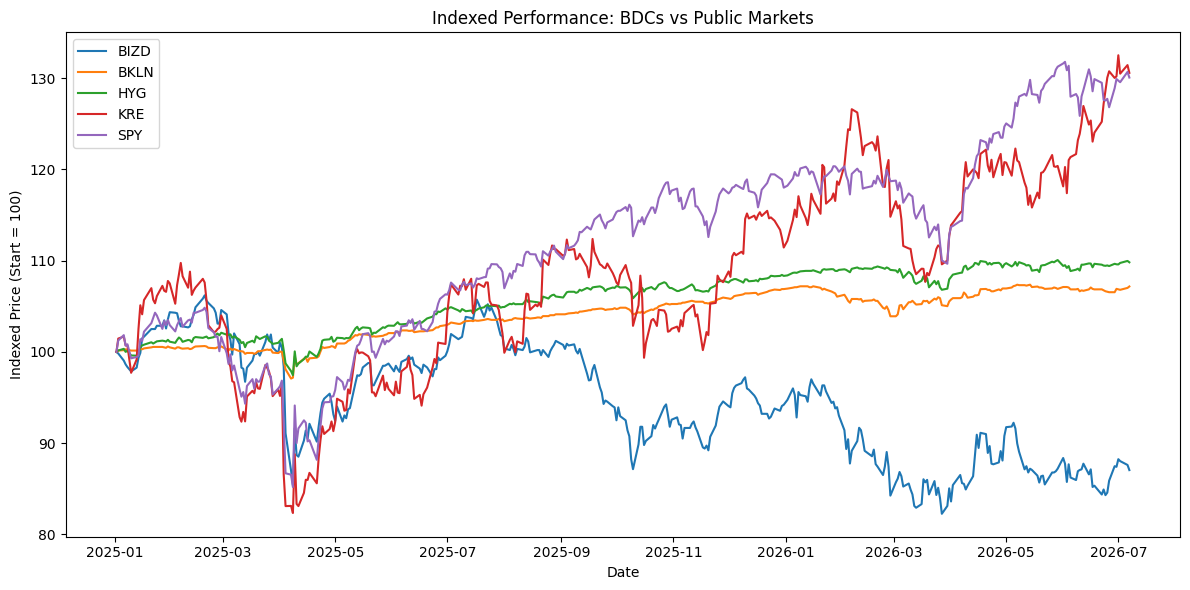

In [6]:
tickers = ["BIZD", "SPY", "HYG", "BKLN", "KRE"]

prices = download_prices(tickers, start="2025-01-01")
indexed = index_prices(prices)

plt.figure(figsize=(12, 6))

for ticker in indexed.columns:
    plt.plot(indexed.index, indexed[ticker], label=ticker)

plt.title("Indexed Performance: BDCs vs Public Markets")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend()
plt.tight_layout()

save_chart("chart_1_bizd_vs_public_markets.png")
plt.show()

Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_1_marked_zones.png


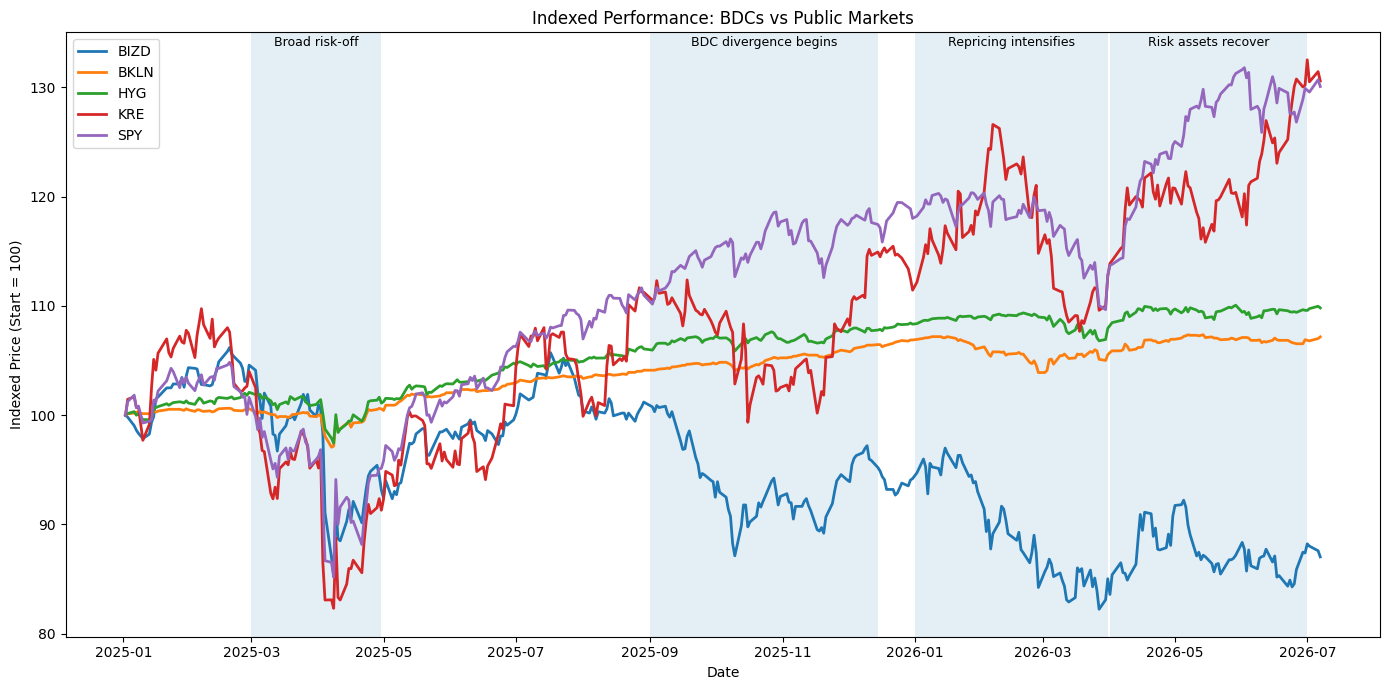

In [7]:
import matplotlib.dates as mdates

# Define zones you want to highlight
zones = [
    {
        "start": "2025-03-01",
        "end": "2025-04-30",
        "label": "Broad risk-off",
        "note": "All risk assets sell off together"
    },
    {
        "start": "2025-09-01",
        "end": "2025-12-15",
        "label": "BDC divergence begins",
        "note": "BIZD weakens while public credit holds up"
    },
    {
        "start": "2026-01-01",
        "end": "2026-03-31",
        "label": "Repricing intensifies",
        "note": "BIZD falls to new lows"
    },
    {
        "start": "2026-04-01",
        "end": "2026-07-01",
        "label": "Risk assets recover",
        "note": "SPY/KRE rally; BIZD stays weak"
    }
]

plt.figure(figsize=(14, 7))

for ticker in indexed.columns:
    plt.plot(indexed.index, indexed[ticker], label=ticker, linewidth=2)

# Add shaded zones
for zone in zones:
    start = pd.to_datetime(zone["start"])
    end = pd.to_datetime(zone["end"])
    plt.axvspan(start, end, alpha=0.12)

    midpoint = start + (end - start) / 2
    plt.text(
        midpoint,
        indexed.max().max() + 1,
        zone["label"],
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=0
    )

plt.title("Indexed Performance: BDCs vs Public Markets")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend()
plt.tight_layout()

save_chart("chart_1_marked_zones.png")
plt.show()

In [8]:
zone_results = []

for zone in zones:
    start = pd.to_datetime(zone["start"])
    end = pd.to_datetime(zone["end"])

    zone_data = indexed.loc[(indexed.index >= start) & (indexed.index <= end)]

    if len(zone_data) > 1:
        zone_return = (zone_data.iloc[-1] / zone_data.iloc[0] - 1) * 100

        for ticker, value in zone_return.items():
            zone_results.append({
                "Zone": zone["label"],
                "Ticker": ticker,
                "Return (%)": value
            })

zone_returns = pd.DataFrame(zone_results)

display(zone_returns.pivot(index="Zone", columns="Ticker", values="Return (%)").round(2))

Ticker,BIZD,BKLN,HYG,KRE,SPY
Zone,,,,,
BDC divergence begins,-5.51,2.25,1.73,3.99,6.61
Broad risk-off,-10.53,0.31,-0.76,-10.94,-4.72
Repricing intensifies,-10.24,-1.32,-0.40,0.44,-4.55
Risk assets recover,5.54,1.06,1.27,16.36,14.11


In [9]:
total_returns = (indexed.iloc[-1] / indexed.iloc[0] - 1) * 100
total_returns = total_returns.sort_values()

print("Total return over full period:")
display(total_returns.round(2))

Total return over full period:


Ticker
BIZD   -12.97
BKLN     7.17
HYG      9.82
SPY     30.08
KRE     30.60
dtype: float64

In [10]:
bizd_return = total_returns["BIZD"]

relative_gap = total_returns - bizd_return
relative_gap = relative_gap.sort_values(ascending=False)

print("How much each benchmark outperformed BIZD:")
display(relative_gap.round(2))

How much each benchmark outperformed BIZD:


Ticker
KRE     43.56
SPY     43.05
HYG     22.79
BKLN    20.14
BIZD     0.00
dtype: float64

Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_2_individual_bdc_performance.png


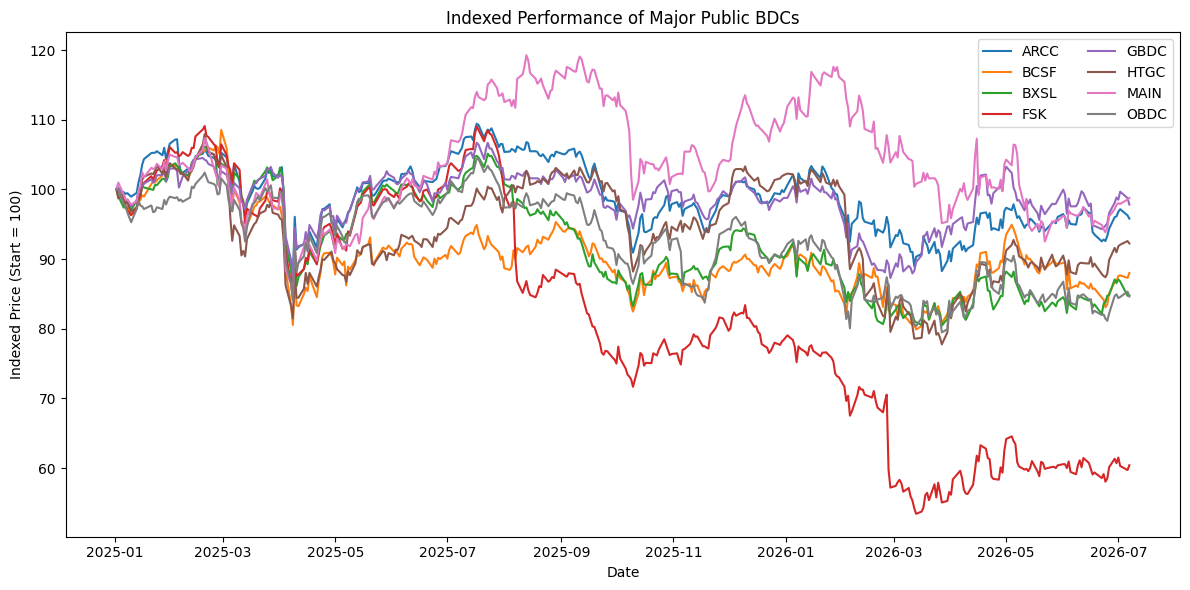

In [11]:
bdc_tickers = ["ARCC", "OBDC", "FSK", "BXSL", "GBDC", "MAIN", "HTGC", "BCSF"]

bdc_prices = download_prices(bdc_tickers, start="2025-01-01")
bdc_indexed = index_prices(bdc_prices)

plt.figure(figsize=(12, 6))

for ticker in bdc_indexed.columns:
    plt.plot(bdc_indexed.index, bdc_indexed[ticker], label=ticker)

plt.title("Indexed Performance of Major Public BDCs")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend(ncol=2)
plt.tight_layout()

save_chart("chart_2_individual_bdc_performance.png")
plt.show()

Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_2_marked_zones.png


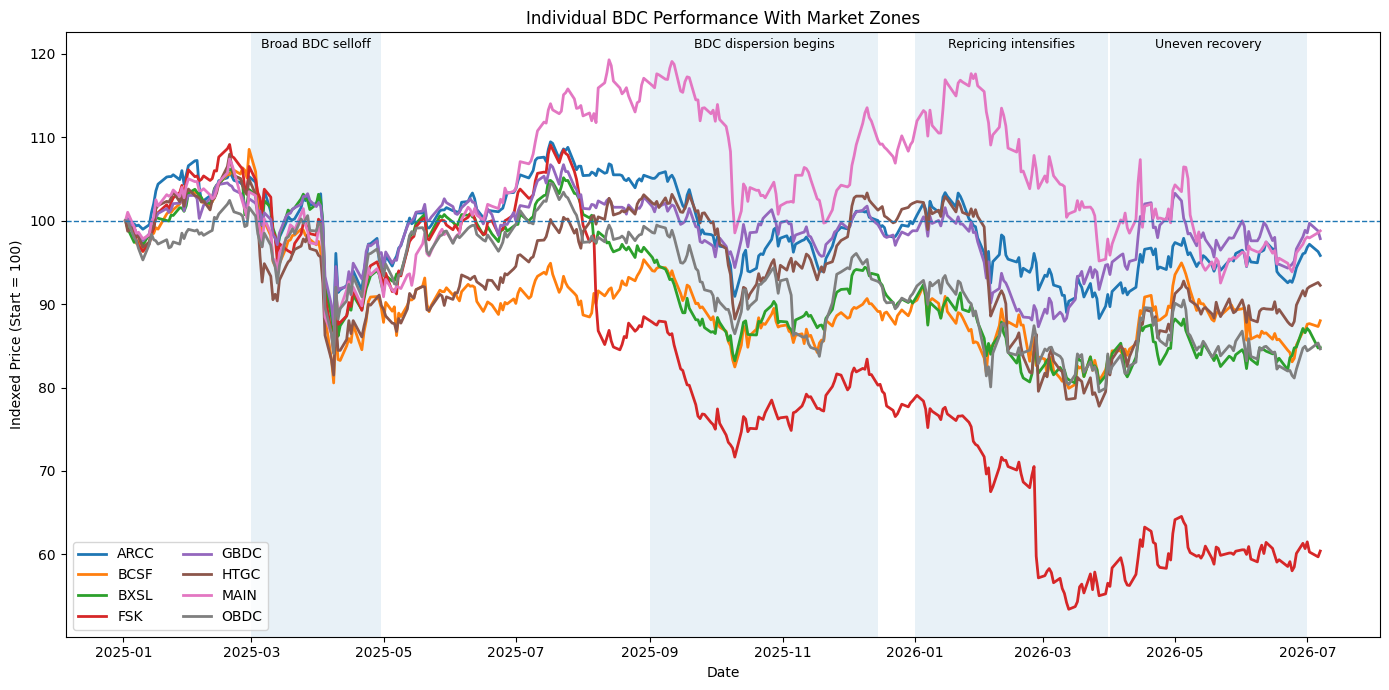

In [12]:
zones = [
    {
        "start": "2025-03-01",
        "end": "2025-04-30",
        "label": "Broad BDC selloff"
    },
    {
        "start": "2025-09-01",
        "end": "2025-12-15",
        "label": "BDC dispersion begins"
    },
    {
        "start": "2026-01-01",
        "end": "2026-03-31",
        "label": "Repricing intensifies"
    },
    {
        "start": "2026-04-01",
        "end": "2026-07-01",
        "label": "Uneven recovery"
    }
]
plt.figure(figsize=(14, 7))

for ticker in bdc_indexed.columns:
    plt.plot(bdc_indexed.index, bdc_indexed[ticker], label=ticker, linewidth=2)

for zone in zones:
    start = pd.to_datetime(zone["start"])
    end = pd.to_datetime(zone["end"])
    plt.axvspan(start, end, alpha=0.10)

    midpoint = start + (end - start) / 2
    plt.text(
        midpoint,
        bdc_indexed.max().max() + 1,
        zone["label"],
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.axhline(100, linestyle="--", linewidth=1)
plt.title("Individual BDC Performance With Market Zones")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend(ncol=2)
plt.tight_layout()

save_chart("chart_2_marked_zones.png")
plt.show()

In [13]:
bdc_total_returns = (bdc_prices.iloc[-1] / bdc_prices.iloc[0] - 1) * 100
bdc_total_returns = bdc_total_returns.sort_values()

print("Total return by BDC since start date:")
display(bdc_total_returns.round(2))

Total return by BDC since start date:


Ticker
FSK    -39.59
OBDC   -15.37
BXSL   -15.19
BCSF   -12.00
HTGC    -7.76
ARCC    -4.19
GBDC    -2.16
MAIN    -1.23
dtype: float64

Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_2_bdc_total_return_ranking.png


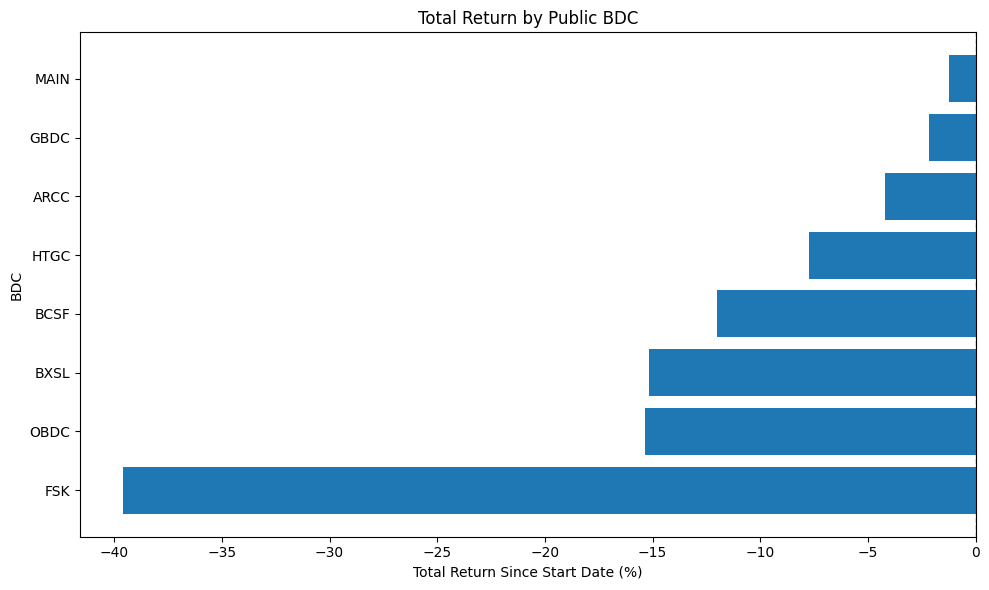

In [14]:
bdc_total_returns_sorted = bdc_total_returns.sort_values()

plt.figure(figsize=(10, 6))
plt.barh(bdc_total_returns_sorted.index, bdc_total_returns_sorted.values)

plt.axvline(0, linestyle="--", linewidth=1)
plt.title("Total Return by Public BDC")
plt.xlabel("Total Return Since Start Date (%)")
plt.ylabel("BDC")
plt.tight_layout()

save_chart("chart_2_bdc_total_return_ranking.png")
plt.show()

In [15]:
best_bdc = bdc_total_returns.idxmax()
worst_bdc = bdc_total_returns.idxmin()

best_return = bdc_total_returns.max()
worst_return = bdc_total_returns.min()
dispersion_gap = best_return - worst_return

print("Best performing BDC:", best_bdc, round(best_return, 2), "%")
print("Worst performing BDC:", worst_bdc, round(worst_return, 2), "%")
print("Performance gap:", round(dispersion_gap, 2), "percentage points")

Best performing BDC: MAIN -1.23 %
Worst performing BDC: FSK -39.59 %
Performance gap: 38.37 percentage points


In [16]:
zone_results = []

for zone in zones:
    start = pd.to_datetime(zone["start"])
    end = pd.to_datetime(zone["end"])

    zone_data = bdc_indexed.loc[
        (bdc_indexed.index >= start) & 
        (bdc_indexed.index <= end)
    ]

    if len(zone_data) > 1:
        zone_return = (zone_data.iloc[-1] / zone_data.iloc[0] - 1) * 100

        for ticker, value in zone_return.items():
            zone_results.append({
                "Zone": zone["label"],
                "Ticker": ticker,
                "Return (%)": value
            })

bdc_zone_returns = pd.DataFrame(zone_results)

display(
    bdc_zone_returns
    .pivot(index="Zone", columns="Ticker", values="Return (%)")
    .round(2)
)

Ticker,ARCC,BCSF,BXSL,FSK,GBDC,HTGC,MAIN,OBDC
Zone,,,,,,,,
BDC dispersion begins,-4.81,-5.20,-2.19,-8.58,-2.12,-0.82,-5.65,-5.94
Broad BDC selloff,-9.03,-15.46,-10.47,-11.08,-5.79,-12.94,-10.20,-6.12
Repricing intensifies,-9.43,-8.04,-7.89,-28.47,-4.10,-19.17,-12.63,-8.85
Uneven recovery,7.94,6.14,5.53,9.51,5.34,12.68,2.27,3.24


Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_3_drawdowns.png


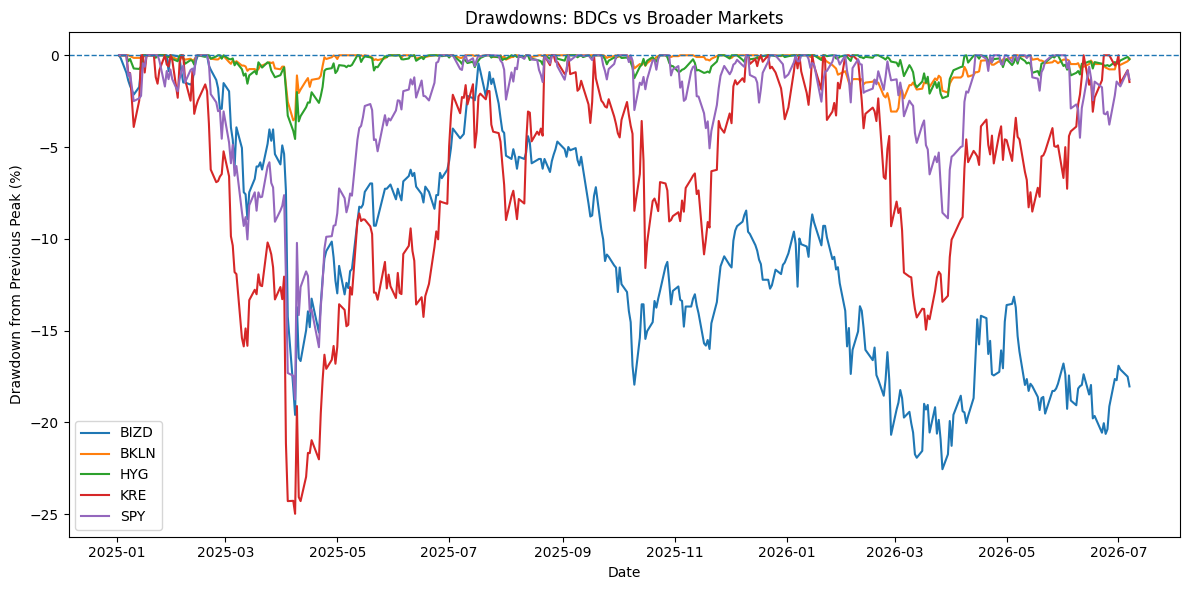

In [17]:
drawdown_tickers = ["BIZD", "SPY", "HYG", "BKLN", "KRE"]

drawdown_prices = download_prices(drawdown_tickers, start="2025-01-01")

rolling_peak = drawdown_prices.cummax()
drawdowns = (drawdown_prices / rolling_peak - 1) * 100

plt.figure(figsize=(12, 6))

for ticker in drawdowns.columns:
    plt.plot(drawdowns.index, drawdowns[ticker], label=ticker)

plt.title("Drawdowns: BDCs vs Broader Markets")
plt.xlabel("Date")
plt.ylabel("Drawdown from Previous Peak (%)")
plt.axhline(0, linestyle="--", linewidth=1)
plt.legend()
plt.tight_layout()

save_chart("chart_3_drawdowns.png")
plt.show()

In [18]:
max_drawdowns = drawdowns.min().sort_values()

print("Maximum drawdown since start date:")
display(max_drawdowns.round(2))

Maximum drawdown since start date:


Ticker
KRE    -24.99
BIZD   -22.56
SPY    -18.76
HYG     -4.56
BKLN    -3.54
dtype: float64

Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_4_bizd_vs_high_yield_spreads.png


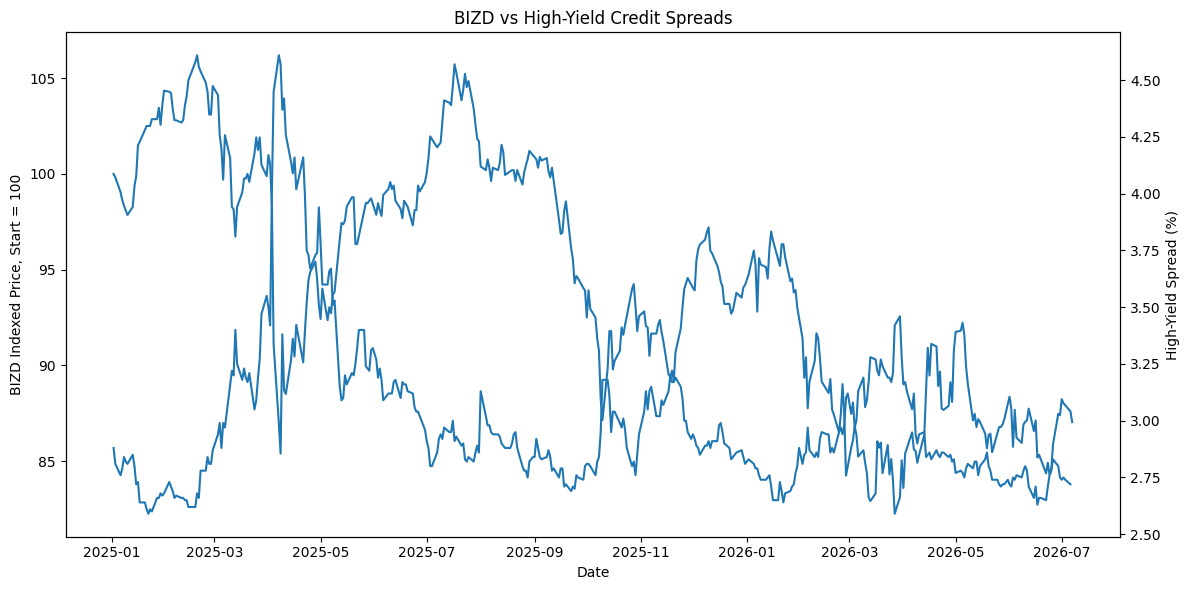

In [19]:
# BIZD price data
bizd = download_prices("BIZD", start="2025-01-01")
bizd_indexed = index_prices(bizd)

# FRED high-yield spread data
fred_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=BAMLH0A0HYM2"
hy_spread = pd.read_csv(fred_url)

hy_spread["observation_date"] = pd.to_datetime(hy_spread["observation_date"])
hy_spread["BAMLH0A0HYM2"] = pd.to_numeric(
    hy_spread["BAMLH0A0HYM2"],
    errors="coerce"
)

hy_spread = hy_spread.dropna()
hy_spread = hy_spread[hy_spread["observation_date"] >= "2025-01-01"]

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(
    bizd_indexed.index,
    bizd_indexed["BIZD"],
    label="BIZD indexed"
)
ax1.set_xlabel("Date")
ax1.set_ylabel("BIZD Indexed Price, Start = 100")

ax2 = ax1.twinx()
ax2.plot(
    hy_spread["observation_date"],
    hy_spread["BAMLH0A0HYM2"],
    label="High-Yield OAS"
)
ax2.set_ylabel("High-Yield Spread (%)")

plt.title("BIZD vs High-Yield Credit Spreads")
fig.tight_layout()

save_chart("chart_4_bizd_vs_high_yield_spreads.png")
plt.show()

In [20]:
print("BIZD start:", round(bizd_indexed["BIZD"].iloc[0], 2))
print("BIZD latest:", round(bizd_indexed["BIZD"].iloc[-1], 2))

print("High-yield spread start:", round(hy_spread["BAMLH0A0HYM2"].iloc[0], 2))
print("High-yield spread latest:", round(hy_spread["BAMLH0A0HYM2"].iloc[-1], 2))
print("High-yield spread max:", round(hy_spread["BAMLH0A0HYM2"].max(), 2))

BIZD start: 100.0
BIZD latest: 87.03
High-yield spread start: 2.88
High-yield spread latest: 2.72
High-yield spread max: 4.61


Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_3_drawdown_gap_all_in_one_with_markers.png


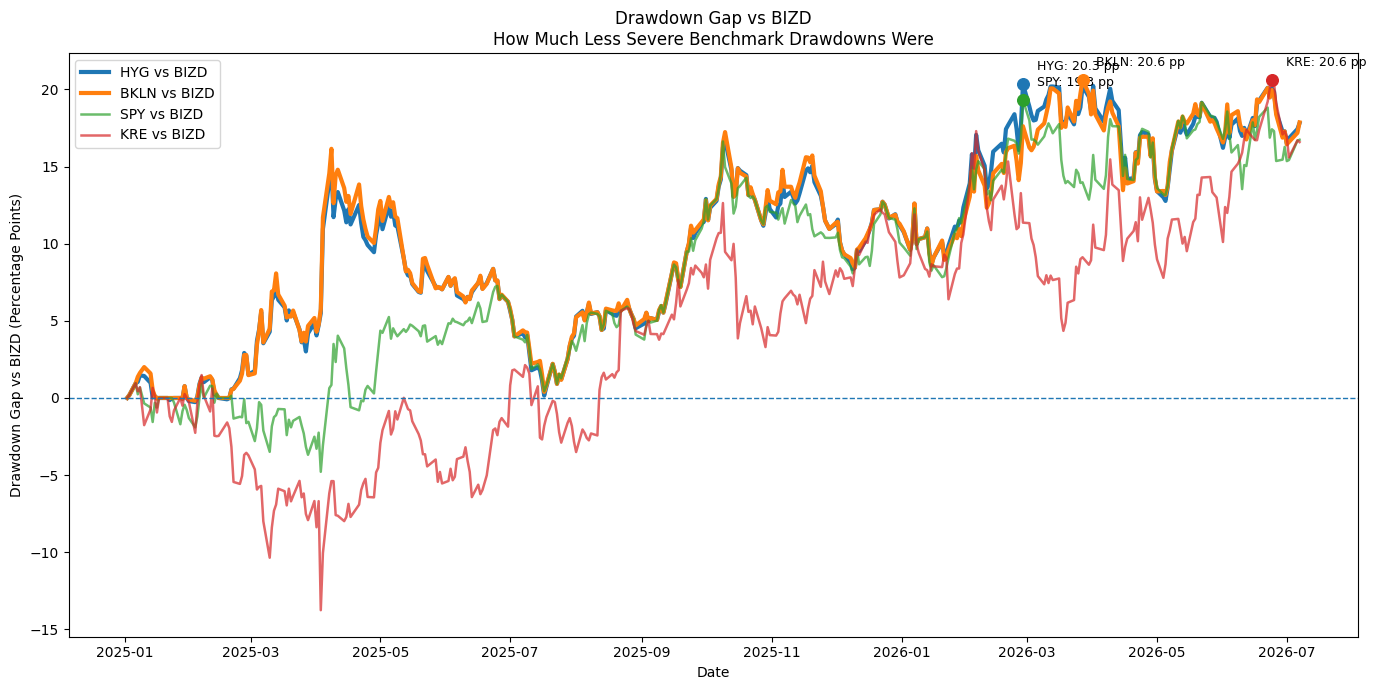

In [21]:
# Assumes you already ran the Chart 3 code and have:
# drawdown_prices
# drawdowns

# If not, uncomment these two lines:
# drawdown_tickers = ["BIZD", "SPY", "HYG", "BKLN", "KRE"]
# drawdowns = (download_prices(drawdown_tickers, start="2025-01-01") / download_prices(drawdown_tickers, start="2025-01-01").cummax() - 1) * 100

gap_df = pd.DataFrame(index=drawdowns.index)

for benchmark in ["HYG", "BKLN", "SPY", "KRE"]:
    gap_df[benchmark] = drawdowns[benchmark] - drawdowns["BIZD"]

plt.figure(figsize=(14, 7))

for benchmark in gap_df.columns:
    # Make HYG and BKLN the main focus
    if benchmark in ["HYG", "BKLN"]:
        plt.plot(gap_df.index, gap_df[benchmark], label=f"{benchmark} vs BIZD", linewidth=3)
    else:
        plt.plot(gap_df.index, gap_df[benchmark], label=f"{benchmark} vs BIZD", linewidth=1.8, alpha=0.7)

    # Mark the maximum gap point
    max_gap_date = gap_df[benchmark].idxmax()
    max_gap_value = gap_df[benchmark].max()

    plt.scatter(max_gap_date, max_gap_value, s=70, zorder=5)
    plt.annotate(
        f"{benchmark}: {max_gap_value:.1f} pp",
        xy=(max_gap_date, max_gap_value),
        xytext=(10, 10),
        textcoords="offset points",
        fontsize=9
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Drawdown Gap vs BIZD\nHow Much Less Severe Benchmark Drawdowns Were")
plt.xlabel("Date")
plt.ylabel("Drawdown Gap vs BIZD (Percentage Points)")
plt.legend()
plt.tight_layout()

save_chart("chart_3_drawdown_gap_all_in_one_with_markers.png")
plt.show()

Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_5_rolling_volatility.png


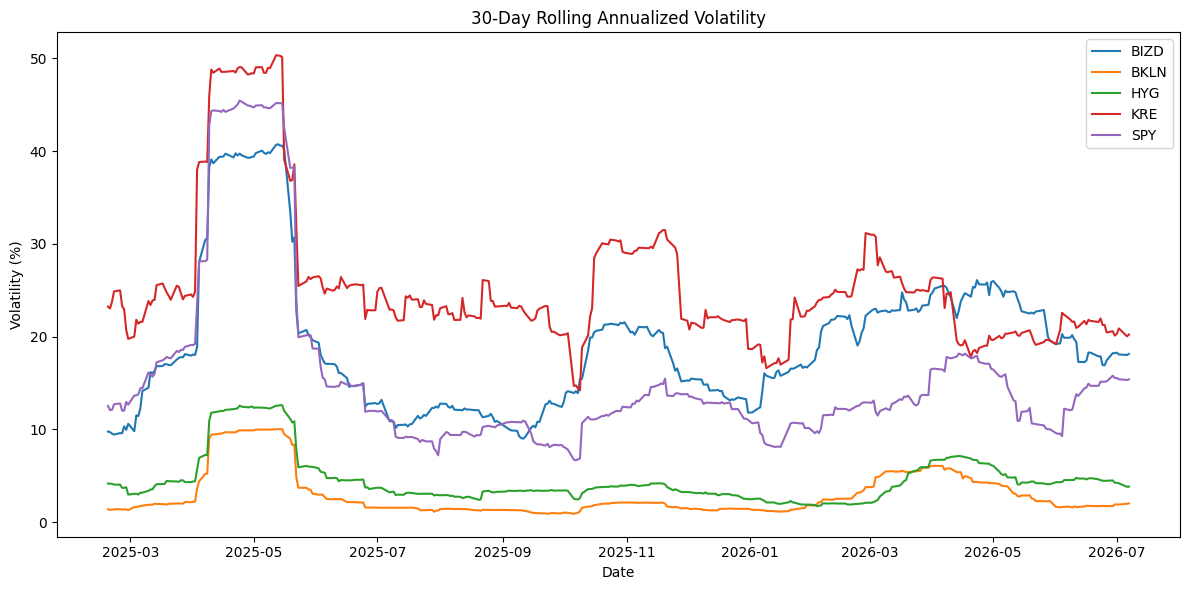

In [22]:
vol_tickers = ["BIZD", "SPY", "HYG", "BKLN", "KRE"]

vol_prices = download_prices(vol_tickers, start="2025-01-01")
vol_returns = vol_prices.pct_change().dropna()

rolling_vol = vol_returns.rolling(30).std() * np.sqrt(252) * 100

plt.figure(figsize=(12, 6))

for ticker in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[ticker], label=ticker)

plt.title("30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend()
plt.tight_layout()

save_chart("chart_5_rolling_volatility.png")
plt.show()

In [23]:
latest_vol = rolling_vol.iloc[-1].sort_values(ascending=False)
avg_vol = rolling_vol.mean().sort_values(ascending=False)
max_vol = rolling_vol.max().sort_values(ascending=False)

vol_summary = pd.DataFrame({
    "Latest 30D Vol (%)": latest_vol,
    "Average 30D Vol (%)": avg_vol,
    "Max 30D Vol (%)": max_vol
})

display(vol_summary.round(2))

,Latest 30D Vol (%),Average 30D Vol (%),Max 30D Vol (%)
Ticker,,,
BIZD,18.15,19.23,40.75
BKLN,2.04,2.97,10.03
HYG,3.85,4.57,12.62
KRE,20.23,25.60,50.34
SPY,15.41,15.54,45.46


In [24]:
print("hello")
2 + 2

hello


4

In [25]:
bdc_tickers = ["ARCC", "OBDC", "FSK", "BXSL", "GBDC", "MAIN", "HTGC", "BCSF"]

bdc_prices = download_prices(bdc_tickers, start="2025-01-01")
bdc_returns = bdc_prices.pct_change().dropna()

display(bdc_returns.head())

Ticker,ARCC,BCSF,BXSL,FSK,GBDC,HTGC,MAIN,OBDC
2025-01-03,-0.001351,-0.001138,-0.009539,-0.002268,0.002620,-0.012758,0.009956,-0.000655
2025-01-06,-0.002705,-0.015955,-0.016775,-0.011818,-0.011104,0.005467,-0.017544,-0.019659
2025-01-07,-0.002261,-0.010423,0.007267,-0.009199,-0.007265,-0.010380,-0.007483,-0.004011
2025-01-08,0.000906,0.002341,0.000627,-0.007428,-0.002661,-0.001998,0.001205,-0.009396
2025-01-10,-0.004980,-0.012259,-0.010972,-0.006548,-0.006004,-0.012513,-0.007906,-0.014227


In [26]:
import statsmodels.api as sm

main_returns = bdc_returns["MAIN"]

regression_results = []

for ticker in bdc_returns.columns:
    if ticker != "MAIN":
        y = bdc_returns[ticker]
        x = main_returns

        # Align the two return series
        regression_data = pd.concat([y, x], axis=1).dropna()
        regression_data.columns = [ticker, "MAIN"]

        y_reg = regression_data[ticker]
        x_reg = sm.add_constant(regression_data["MAIN"])

        model = sm.OLS(y_reg, x_reg).fit()

        correlation = regression_data[ticker].corr(regression_data["MAIN"])

        regression_results.append({
            "BDC": ticker,
            "Correlation with MAIN": correlation,
            "Beta to MAIN": model.params["MAIN"],
            "Alpha Daily (%)": model.params["const"] * 100,
            "R-squared": model.rsquared,
            "P-value": model.pvalues["MAIN"]
        })

main_regression_table = pd.DataFrame(regression_results)

main_regression_table = main_regression_table.sort_values(
    "Correlation with MAIN",
    ascending=False
)

display(main_regression_table.round(4))

,BDC,Correlation with MAIN,Beta to MAIN,Alpha Daily (%),R-squared,P-value
0,ARCC,0.7639,0.6505,-0.0083,0.5836,0.0
5,HTGC,0.7195,0.6880,-0.0163,0.5177,0.0
2,BXSL,0.7154,0.6326,-0.0398,0.5118,0.0
6,OBDC,0.7021,0.6753,-0.0390,0.4930,0.0
4,GBDC,0.6853,0.5498,-0.0028,0.4696,0.0
1,BCSF,0.6845,0.6479,-0.0287,0.4685,0.0
3,FSK,0.6016,0.7095,-0.1226,0.3619,0.0


In [27]:
# Make sure you already have bdc_prices and bdc_indexed from Chart 2
# If not, rerun this:
bdc_tickers = ["ARCC", "BCSF", "BXSL", "FSK", "GBDC", "HTGC", "MAIN", "OBDC"]

bdc_prices = download_prices(bdc_tickers, start="2025-01-01")
bdc_indexed = index_prices(bdc_prices)

# Define peer group excluding FSK
peer_tickers_ex_fsk = [ticker for ticker in bdc_indexed.columns if ticker != "FSK"]

# Equal-weight peer basket excluding FSK
peer_basket_ex_fsk = bdc_indexed[peer_tickers_ex_fsk].mean(axis=1)

# FSK deviation from peer basket
fsk_deviation = bdc_indexed["FSK"] - peer_basket_ex_fsk

display(peer_basket_ex_fsk.head())
display(fsk_deviation.head())

2025-01-02    100.000000
2025-01-03     99.816222
2025-01-06     98.696890
2025-01-07     98.207160
2025-01-08     98.081850
dtype: float64

2025-01-02    0.000000
2025-01-03   -0.042979
2025-01-06   -0.102799
2025-01-07   -0.520083
2025-01-08   -1.120401
dtype: float64

Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_2_fsk_vs_peer_basket_ex_fsk.png


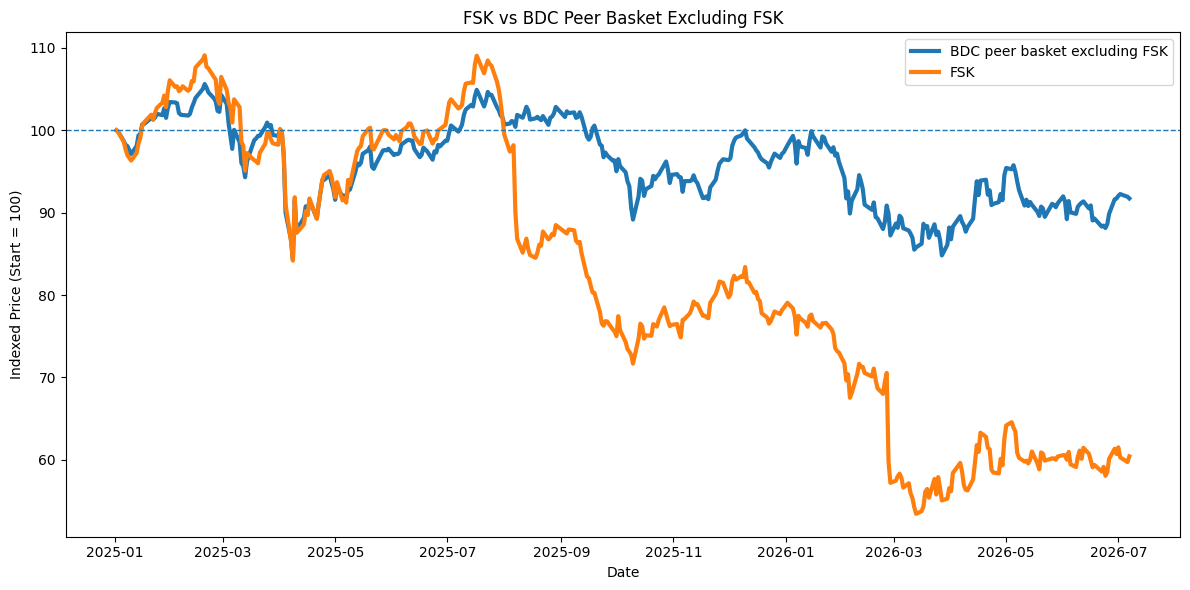

In [28]:
plt.figure(figsize=(12, 6))

plt.plot(peer_basket_ex_fsk.index, peer_basket_ex_fsk, label="BDC peer basket excluding FSK", linewidth=3)
plt.plot(bdc_indexed.index, bdc_indexed["FSK"], label="FSK", linewidth=3)

plt.axhline(100, linestyle="--", linewidth=1)

plt.title("FSK vs BDC Peer Basket Excluding FSK")
plt.xlabel("Date")
plt.ylabel("Indexed Price (Start = 100)")
plt.legend()
plt.tight_layout()

save_chart("chart_2_fsk_vs_peer_basket_ex_fsk.png")
plt.show()

Saved: C:\Users\jacob\OneDrive\Substack - Coding Folders\private-credit-article\outputs\chart_2_fsk_deviation_from_peer_basket.png


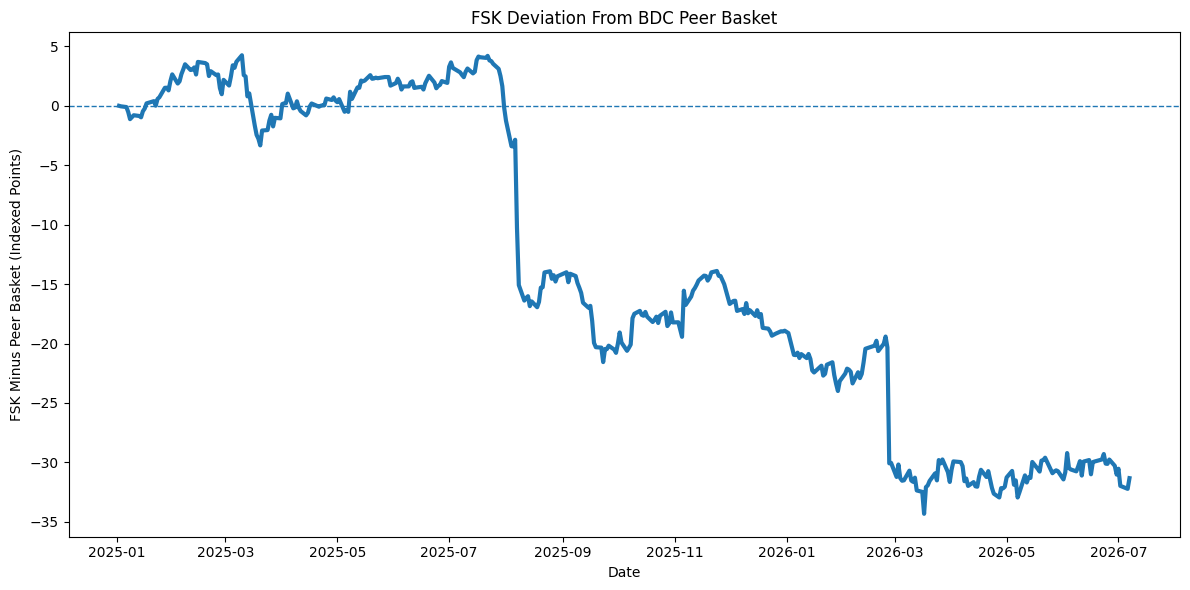

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(fsk_deviation.index, fsk_deviation, linewidth=3)

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("FSK Deviation From BDC Peer Basket")
plt.xlabel("Date")
plt.ylabel("FSK Minus Peer Basket (Indexed Points)")
plt.tight_layout()

save_chart("chart_2_fsk_deviation_from_peer_basket.png")
plt.show()

In [30]:
fsk_final_value = bdc_indexed["FSK"].iloc[-1]
peer_final_value = peer_basket_ex_fsk.iloc[-1]
final_deviation = fsk_deviation.iloc[-1]

max_negative_deviation = fsk_deviation.min()
max_negative_deviation_date = fsk_deviation.idxmin()

fsk_total_return = (bdc_prices["FSK"].iloc[-1] / bdc_prices["FSK"].iloc[0] - 1) * 100

peer_basket_price = bdc_prices[peer_tickers_ex_fsk].mean(axis=1)
peer_total_return = (peer_basket_ex_fsk.iloc[-1] / peer_basket_ex_fsk.iloc[0] - 1) * 100

print("FSK final indexed value:", round(fsk_final_value, 2))
print("Peer basket final indexed value:", round(peer_final_value, 2))
print("Final FSK deviation from peers:", round(final_deviation, 2), "indexed points")
print("Maximum negative FSK deviation:", round(max_negative_deviation, 2), "indexed points")
print("Date of maximum negative deviation:", max_negative_deviation_date.date())
print()
print("FSK total return:", round(fsk_total_return, 2), "%")
print("Peer basket total return:", round(peer_total_return, 2), "%")
print("FSK underperformance vs peer basket:", round(fsk_total_return - peer_total_return, 2), "percentage points")

FSK final indexed value: 60.41
Peer basket final indexed value: 91.73
Final FSK deviation from peers: -31.32 indexed points
Maximum negative FSK deviation: -34.32 indexed points
Date of maximum negative deviation: 2026-03-17

FSK total return: -39.59 %
Peer basket total return: -8.27 %
FSK underperformance vs peer basket: -31.32 percentage points


In [32]:
bdc_returns = bdc_prices.pct_change().dropna()

peer_returns_ex_fsk = bdc_returns[peer_tickers_ex_fsk]

# Average pairwise correlation among all non-FSK BDCs
peer_corr_matrix = peer_returns_ex_fsk.corr()

# Get only the off-diagonal correlations
peer_corr_values = []

for i in range(len(peer_corr_matrix.columns)):
    for j in range(i + 1, len(peer_corr_matrix.columns)):
        peer_corr_values.append(peer_corr_matrix.iloc[i, j])

average_peer_correlation = np.mean(peer_corr_values)

# FSK correlation with the peer basket
peer_basket_returns = peer_returns_ex_fsk.mean(axis=1)
fsk_returns = bdc_returns["FSK"]

fsk_corr_with_peer_basket = fsk_returns.corr(peer_basket_returns)

print("Average correlation among non-FSK BDCs:", round(average_peer_correlation, 3))
print("FSK correlation with non-FSK peer basket:", round(fsk_corr_with_peer_basket, 3))

Average correlation among non-FSK BDCs: 0.751
FSK correlation with non-FSK peer basket: 0.747


In [1]:
%pip install yfinance pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Automatically calculate the previous 10 years
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=10)

# Download WTI crude oil front-month futures data
oil_data = yf.download(
    "CL=F",
    start=start_date,
    end=end_date + pd.Timedelta(days=1),
    auto_adjust=False,
    progress=False
)

# Extract closing prices
oil_prices = oil_data["Close"].squeeze().dropna()

oil_prices.tail()

2026-07-17    82.489998
2026-07-20    83.230003
2026-07-21    84.910004
2026-07-22    86.830002
2026-07-23    92.190002
Name: CL=F, dtype: float64

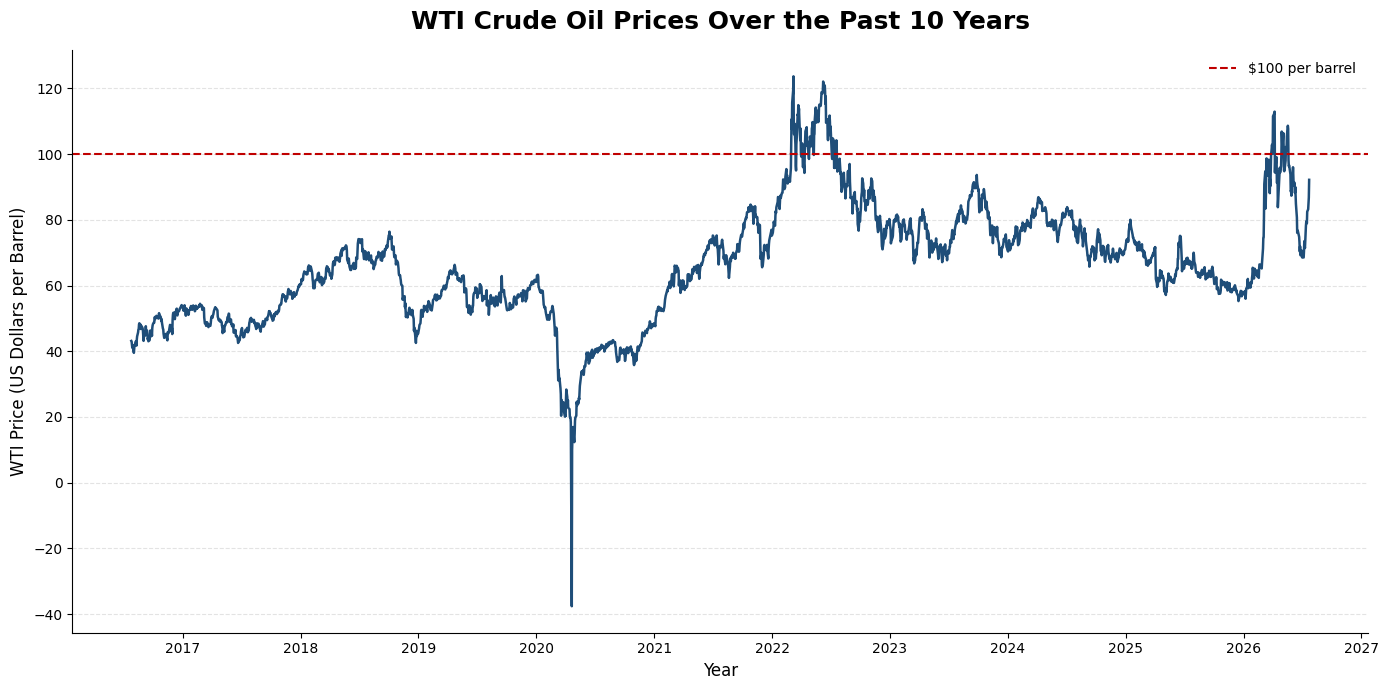

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    oil_prices.index,
    oil_prices,
    color="#1F4E79",
    linewidth=1.8
)

ax.axhline(
    y=100,
    color="#C00000",
    linestyle="--",
    linewidth=1.5,
    label="$100 per barrel"
)

ax.set_title(
    "WTI Crude Oil Prices Over the Past 10 Years",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_subtitle = None
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("WTI Price (US Dollars per Barrel)", fontsize=12)

# Show one label for each year
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=10)

# BZ=F is the Yahoo Finance ticker for Brent crude oil futures
brent_data = yf.download(
    "BZ=F",
    start=start_date,
    end=end_date + pd.Timedelta(days=1),
    auto_adjust=False,
    progress=False
)

brent_prices = brent_data["Close"].squeeze().dropna()

brent_prices.tail()

2026-07-17     88.099998
2026-07-20     89.220001
2026-07-21     91.010002
2026-07-22     94.070000
2026-07-23    100.519997
Name: BZ=F, dtype: float64

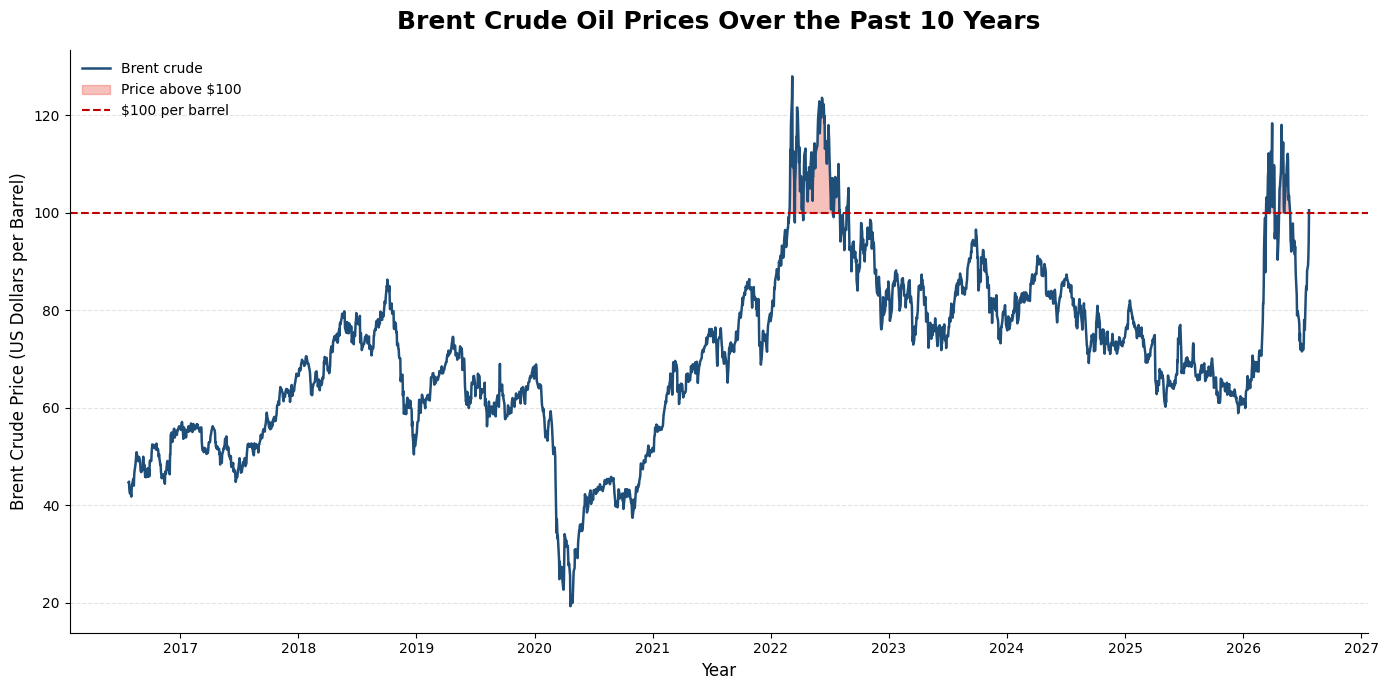

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))

# Plot Brent prices
ax.plot(
    brent_prices.index,
    brent_prices,
    color="#1F4E79",
    linewidth=1.8,
    label="Brent crude"
)

# Shade areas where Brent is above $100
ax.fill_between(
    brent_prices.index,
    100,
    brent_prices.values,
    where=(brent_prices.values > 100),
    interpolate=True,
    color="#E74C3C",
    alpha=0.35,
    label="Price above $100"
)

# Add the $100 threshold
ax.axhline(
    y=100,
    color="#C00000",
    linestyle="--",
    linewidth=1.5,
    label="$100 per barrel"
)

ax.set_title(
    "Brent Crude Oil Prices Over the Past 10 Years",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Brent Crude Price (US Dollars per Barrel)", fontsize=12)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [12]:
# Save the chart as a high-resolution PNG
fig.savefig(
    "brent_crude_above_100.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Chart saved as brent_crude_above_100.png")

Chart saved as brent_crude_above_100.png


In [13]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=10)

# Download adjusted Domino's stock prices
dpz_data = yf.download(
    "DPZ",
    start=start_date,
    end=end_date + pd.Timedelta(days=1),
    auto_adjust=True,
    progress=False
)

# Download Brent crude oil futures prices
brent_data = yf.download(
    "BZ=F",
    start=start_date,
    end=end_date + pd.Timedelta(days=1),
    auto_adjust=False,
    progress=False
)

dpz_prices = dpz_data["Close"].squeeze().dropna()
brent_prices = brent_data["Close"].squeeze().dropna()

print("Domino's data:")
display(dpz_prices.head())

print("Brent data:")
display(brent_prices.head())

Domino's data:


2016-07-25    131.527084
2016-07-26    130.137802
2016-07-27    131.117462
2016-07-28    131.135269
2016-07-29    131.179794
Name: DPZ, dtype: float64

Brent data:


2016-07-25    44.720001
2016-07-26    44.869999
2016-07-27    43.470001
2016-07-28    42.700001
2016-07-29    42.459999
Name: BZ=F, dtype: float64

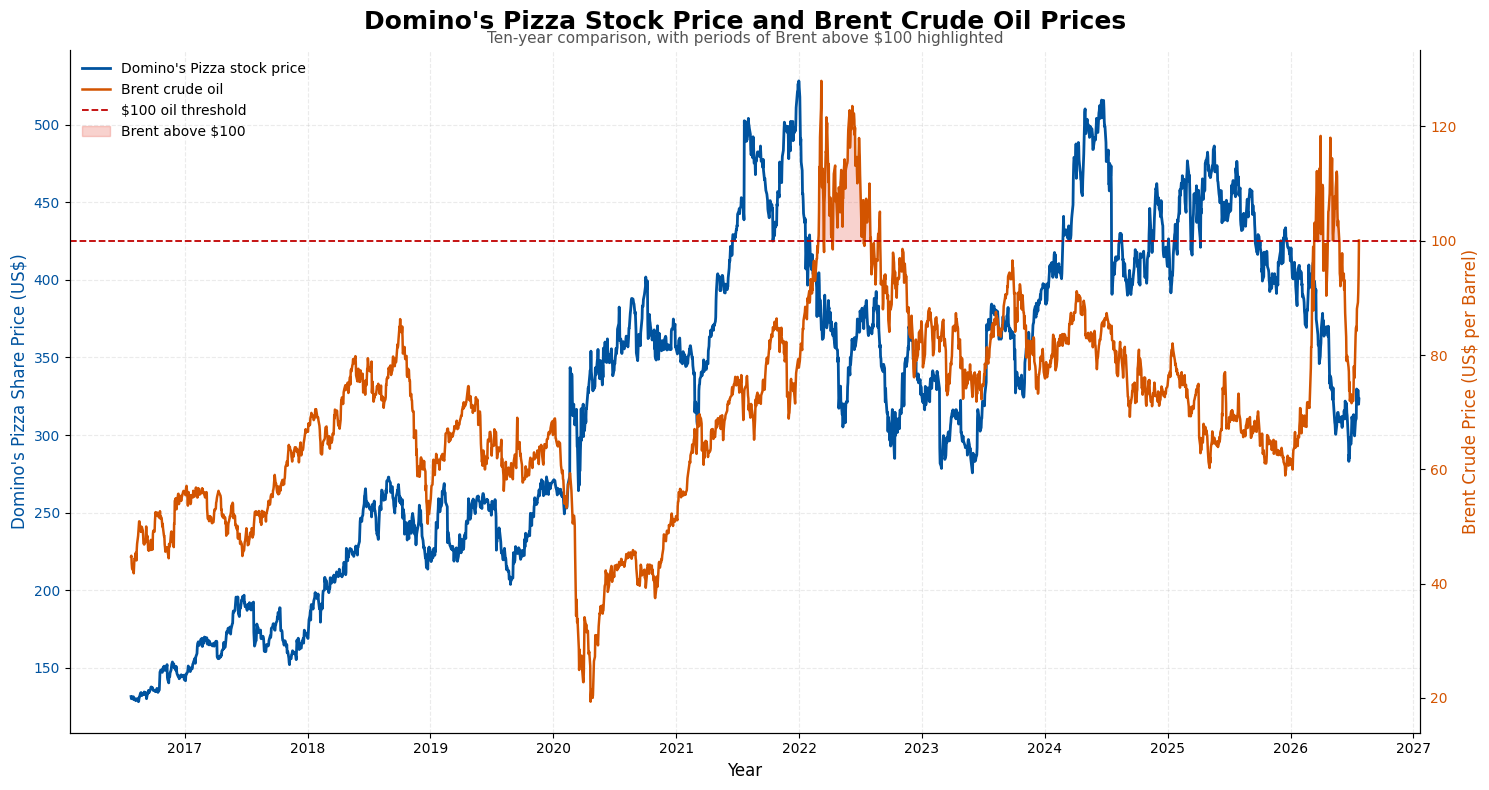

Chart saved as dominos_stock_vs_brent_oil_10_years.png


In [14]:
fig, ax1 = plt.subplots(figsize=(15, 8))

# Domino's Pizza stock price — left axis
dpz_line = ax1.plot(
    dpz_prices.index,
    dpz_prices,
    color="#00539F",
    linewidth=2,
    label="Domino's Pizza stock price"
)

ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel(
    "Domino's Pizza Share Price (US$)",
    color="#00539F",
    fontsize=12
)
ax1.tick_params(axis="y", labelcolor="#00539F")

# Brent crude price — right axis
ax2 = ax1.twinx()

brent_line = ax2.plot(
    brent_prices.index,
    brent_prices,
    color="#D35400",
    linewidth=1.8,
    label="Brent crude oil"
)

ax2.set_ylabel(
    "Brent Crude Price (US$ per Barrel)",
    color="#D35400",
    fontsize=12
)
ax2.tick_params(axis="y", labelcolor="#D35400")

# Highlight areas where Brent is above $100
ax2.fill_between(
    brent_prices.index,
    100,
    brent_prices.values,
    where=(brent_prices.values > 100),
    interpolate=True,
    color="#E74C3C",
    alpha=0.25,
    label="Brent above $100"
)

# Add $100 threshold
threshold_line = ax2.axhline(
    y=100,
    color="#C00000",
    linestyle="--",
    linewidth=1.3,
    label="$100 oil threshold"
)

ax1.set_title(
    "Domino's Pizza Stock Price and Brent Crude Oil Prices",
    fontsize=18,
    fontweight="bold",
    pad=15
)

ax1.text(
    0.5,
    1.01,
    "Ten-year comparison, with periods of Brent above $100 highlighted",
    transform=ax1.transAxes,
    ha="center",
    fontsize=11,
    color="#555555"
)

# Format dates
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Combine legends from both axes
lines = dpz_line + brent_line + [threshold_line]
labels = [line.get_label() for line in lines]

# Add shaded-region legend entry
handles2, labels2 = ax2.get_legend_handles_labels()
if "Brent above $100" in labels2:
    position = labels2.index("Brent above $100")
    lines.append(handles2[position])
    labels.append(labels2[position])

ax1.legend(
    lines,
    labels,
    loc="upper left",
    frameon=False
)

ax1.grid(axis="both", linestyle="--", alpha=0.25)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()

# Save a high-resolution copy
fig.savefig(
    "dominos_stock_vs_brent_oil_10_years.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Chart saved as dominos_stock_vs_brent_oil_10_years.png")

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set a rolling ten-year period
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=10)

start_text = start_date.strftime("%Y-%m-%d")
end_text = end_date.strftime("%Y-%m-%d")

# FRED download URLs
brent_url = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    f"?id=DCOILBRENTEU&cosd={start_text}&coed={end_text}"
)

gas_url = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    f"?id=GASREGW&cosd={start_text}&coed={end_text}"
)

# Download without assuming the date-column name
brent = pd.read_csv(brent_url)
gas = pd.read_csv(gas_url)

# Rename the first column to "date"
# This works whether FRED calls it DATE or observation_date
brent = brent.rename(
    columns={
        brent.columns[0]: "date",
        "DCOILBRENTEU": "brent_price"
    }
)

gas = gas.rename(
    columns={
        gas.columns[0]: "date",
        "GASREGW": "gas_price"
    }
)

# Convert the date columns
brent["date"] = pd.to_datetime(brent["date"])
gas["date"] = pd.to_datetime(gas["date"])

# Convert price columns to numeric
brent["brent_price"] = pd.to_numeric(
    brent["brent_price"],
    errors="coerce"
)

gas["gas_price"] = pd.to_numeric(
    gas["gas_price"],
    errors="coerce"
)

# Remove missing observations
brent = brent.dropna(subset=["brent_price"])
gas = gas.dropna(subset=["gas_price"])

# Convert daily Brent prices into weekly averages ending Monday
brent_weekly = (
    brent.set_index("date")["brent_price"]
    .resample("W-MON")
    .mean()
    .reset_index()
)

# Merge Brent and gasoline observations
combined = pd.merge(
    brent_weekly,
    gas,
    on="date",
    how="inner"
)

display(combined.head())
print(f"Number of weekly observations: {len(combined)}")

,date,brent_price,gas_price
0,2016-07-25,43.760,2.182
1,2016-08-01,41.828,2.159
2,2016-08-08,41.498,2.150
3,2016-08-15,44.444,2.149
4,2016-08-22,48.760,2.193


Number of weekly observations: 522


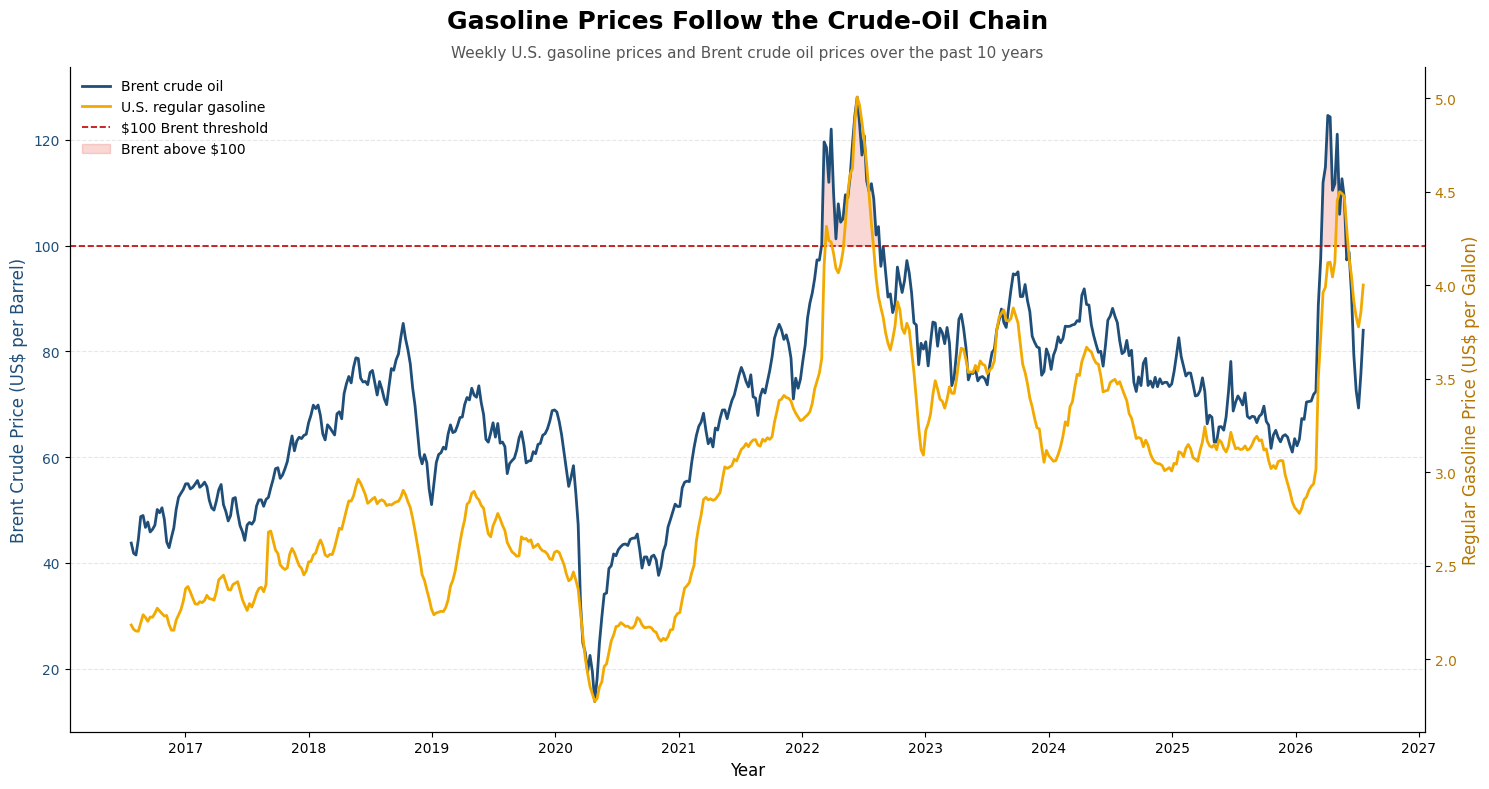

Chart saved as gasoline_vs_brent_crude_10_years.png


In [17]:
fig, ax1 = plt.subplots(figsize=(15, 8))

# Brent crude — left axis
brent_line = ax1.plot(
    combined["date"],
    combined["brent_price"],
    color="#1F4E79",
    linewidth=2,
    label="Brent crude oil"
)

ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel(
    "Brent Crude Price (US$ per Barrel)",
    color="#1F4E79",
    fontsize=12
)

ax1.tick_params(axis="y", labelcolor="#1F4E79")

# Highlight periods when Brent exceeded $100
above_100 = ax1.fill_between(
    combined["date"],
    100,
    combined["brent_price"],
    where=(combined["brent_price"] > 100),
    interpolate=True,
    color="#E74C3C",
    alpha=0.22,
    label="Brent above $100"
)

threshold_line = ax1.axhline(
    100,
    color="#C00000",
    linestyle="--",
    linewidth=1.2,
    label="$100 Brent threshold"
)

# Gasoline — right axis
ax2 = ax1.twinx()

gas_line = ax2.plot(
    combined["date"],
    combined["gas_price"],
    color="#F2A900",
    linewidth=2,
    label="U.S. regular gasoline"
)

ax2.set_ylabel(
    "Regular Gasoline Price (US$ per Gallon)",
    color="#B57600",
    fontsize=12
)

ax2.tick_params(axis="y", labelcolor="#B57600")

# Titles
ax1.set_title(
    "Gasoline Prices Follow the Crude-Oil Chain",
    fontsize=18,
    fontweight="bold",
    pad=28
)

ax1.text(
    0.5,
    1.015,
    "Weekly U.S. gasoline prices and Brent crude oil prices over the past 10 years",
    transform=ax1.transAxes,
    ha="center",
    fontsize=11,
    color="#555555"
)

# Format x-axis
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Combine legends
legend_items = brent_line + gas_line + [threshold_line, above_100]
legend_labels = [item.get_label() for item in legend_items]

ax1.legend(
    legend_items,
    legend_labels,
    loc="upper left",
    frameon=False
)

# Styling
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

plt.tight_layout()

# Save before displaying
fig.savefig(
    "gasoline_vs_brent_crude_10_years.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Chart saved as gasoline_vs_brent_crude_10_years.png")

In [1]:
%pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


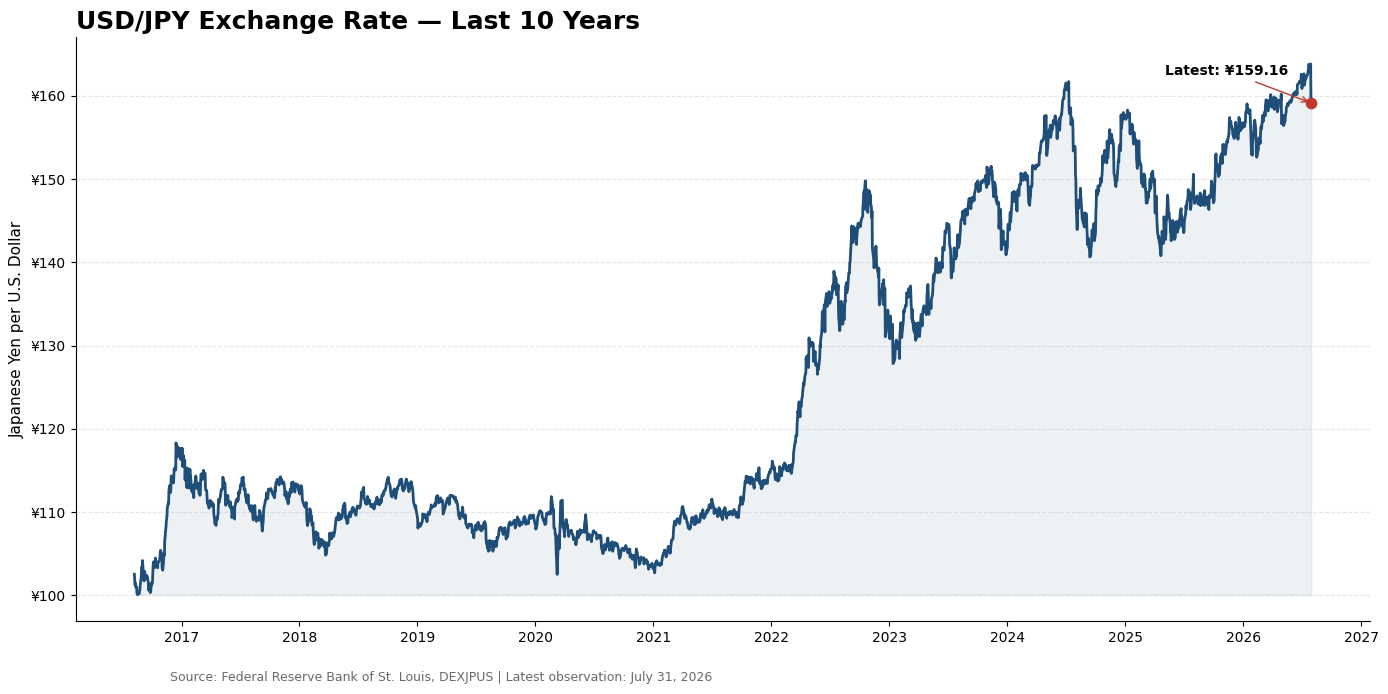

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Set the date range to the most recent 10 years
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=10)

# Download USD/JPY data from FRED
url = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    f"?id=DEXJPUS&cosd={start_date:%Y-%m-%d}&coed={end_date:%Y-%m-%d}"
)

usd_jpy = pd.read_csv(url)

# FRED may call the first column DATE or observation_date,
# so rename it based on its position
usd_jpy = usd_jpy.rename(
    columns={
        usd_jpy.columns[0]: "Date",
        "DEXJPUS": "USD_JPY"
    }
)

# Clean the data
usd_jpy["Date"] = pd.to_datetime(usd_jpy["Date"])
usd_jpy["USD_JPY"] = pd.to_numeric(
    usd_jpy["USD_JPY"],
    errors="coerce"
)

usd_jpy = (
    usd_jpy
    .dropna(subset=["USD_JPY"])
    .sort_values("Date")
)

# Obtain the latest observation
latest_date = usd_jpy["Date"].iloc[-1]
latest_rate = usd_jpy["USD_JPY"].iloc[-1]

# Create the graph
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    usd_jpy["Date"],
    usd_jpy["USD_JPY"],
    color="#1f4e79",
    linewidth=2
)

ax.fill_between(
    usd_jpy["Date"],
    usd_jpy["USD_JPY"],
    usd_jpy["USD_JPY"].min(),
    color="#1f4e79",
    alpha=0.08
)

# Mark the latest exchange rate
ax.scatter(
    latest_date,
    latest_rate,
    color="#c0392b",
    s=55,
    zorder=3
)

ax.annotate(
    f"Latest: ¥{latest_rate:.2f}",
    xy=(latest_date, latest_rate),
    xytext=(-105, 20),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#c0392b")
)

# Formatting
ax.set_title(
    "USD/JPY Exchange Rate — Last 10 Years",
    fontsize=18,
    fontweight="bold",
    loc="left"
)

ax.set_subtitle = None
ax.set_xlabel("")
ax.set_ylabel("Japanese Yen per U.S. Dollar", fontsize=11)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"¥{value:.0f}")
)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.125,
    0.02,
    f"Source: Federal Reserve Bank of St. Louis, DEXJPUS | "
    f"Latest observation: {latest_date:%B %d, %Y}",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

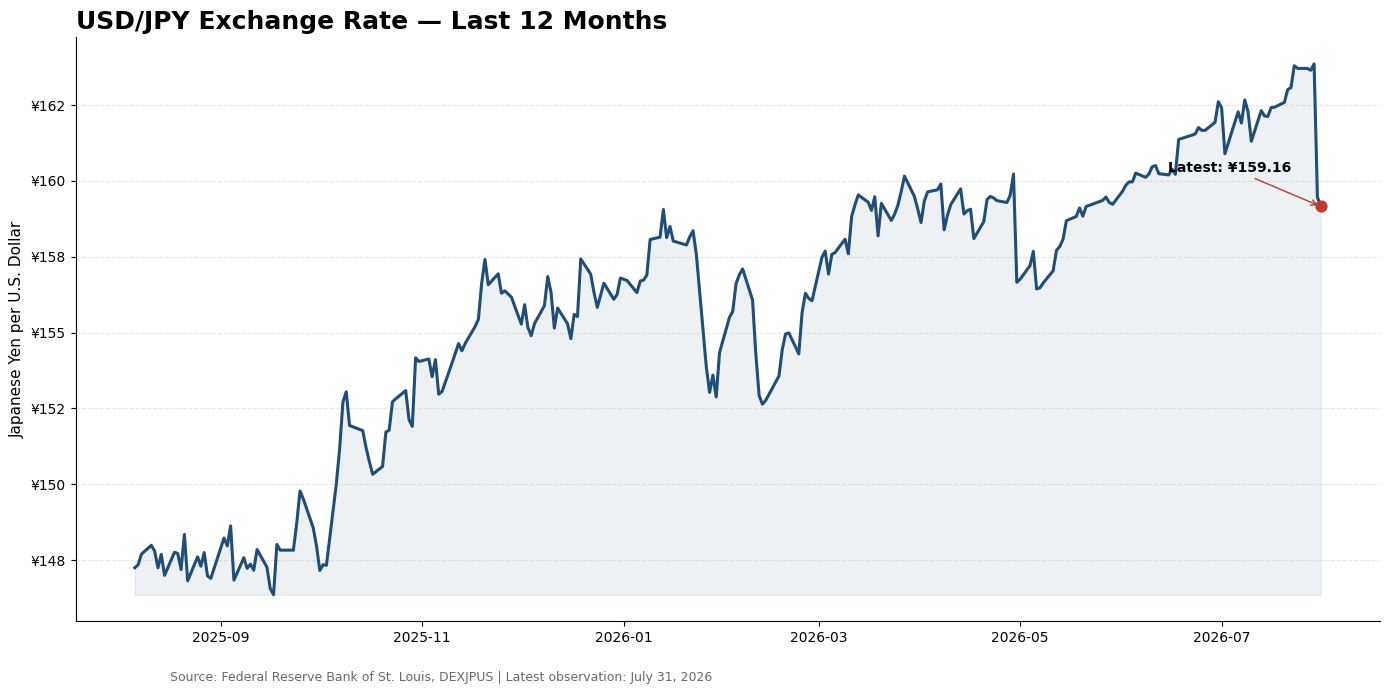

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Set date range to the latest 12 months
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=1)

# Download USD/JPY exchange-rate data from FRED
url = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    f"?id=DEXJPUS&cosd={start_date:%Y-%m-%d}&coed={end_date:%Y-%m-%d}"
)

usd_jpy = pd.read_csv(url)

# Rename columns safely
usd_jpy = usd_jpy.rename(
    columns={
        usd_jpy.columns[0]: "Date",
        "DEXJPUS": "USD_JPY"
    }
)

# Clean the data
usd_jpy["Date"] = pd.to_datetime(usd_jpy["Date"])
usd_jpy["USD_JPY"] = pd.to_numeric(
    usd_jpy["USD_JPY"],
    errors="coerce"
)

usd_jpy = (
    usd_jpy
    .dropna(subset=["USD_JPY"])
    .sort_values("Date")
)

# Get the latest observation
latest_date = usd_jpy["Date"].iloc[-1]
latest_rate = usd_jpy["USD_JPY"].iloc[-1]

# Create the graph
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    usd_jpy["Date"],
    usd_jpy["USD_JPY"],
    color="#1f4e79",
    linewidth=2.2
)

ax.fill_between(
    usd_jpy["Date"],
    usd_jpy["USD_JPY"],
    usd_jpy["USD_JPY"].min(),
    color="#1f4e79",
    alpha=0.08
)

# Mark the latest rate
ax.scatter(
    latest_date,
    latest_rate,
    color="#c0392b",
    s=60,
    zorder=3
)

ax.annotate(
    f"Latest: ¥{latest_rate:.2f}",
    xy=(latest_date, latest_rate),
    xytext=(-110, 25),
    textcoords="offset points",
    fontsize=10,
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#c0392b")
)

# Format the chart
ax.set_title(
    "USD/JPY Exchange Rate — Last 12 Months",
    fontsize=18,
    fontweight="bold",
    loc="left"
)

ax.set_xlabel("")
ax.set_ylabel("Japanese Yen per U.S. Dollar", fontsize=11)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda value, position: f"¥{value:.0f}")
)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.grid(axis="x", visible=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.125,
    0.02,
    f"Source: Federal Reserve Bank of St. Louis, DEXJPUS | "
    f"Latest observation: {latest_date:%B %d, %Y}",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Save as a high-resolution image
fig.savefig(
    "usd_jpy_last_12_months.png",
    dpi=300,
    bbox_inches="tight"
)